# 03: Baseline Evaluation

Phase 1. Retrieval ablation for `dense_only`, `sparse_only`, `dense_sparse`.
Saves `results/baseline_ablation.csv`. Does NOT load the knowledge graph.

Run after notebook 01 (ChromaDB index must exist).

## Cell group 1: Imports and constants

In [1]:
import json
import math
import sys
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100

from dotenv import load_dotenv
load_dotenv()

SCRIPTS_DIR = Path('scripts').resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from retriever import (
    load_dense_sparse,
    dense_only_retrieve, sparse_only_retrieve,
    dense_retrieve, sparse_retrieve, rrf_fuse,
)

DATA_DIR    = Path('data')
CHROMA_DIR  = DATA_DIR / 'chroma_db'
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

EVAL_K        = [1, 3, 5, 10]
RRF_K         = 60
TOP_K         = 10
RAGAS_ENABLED = True

BASELINE_CONFIGS = {
    'dense_only':   'Dense (ChromaDB only)',
    'sparse_only':  'Sparse (BM25 only)',
    'dense_sparse': 'Dense + Sparse (no graph)',
}

print(f'EVAL_K: {EVAL_K}')
print(f'RAGAS_ENABLED: {RAGAS_ENABLED}')
print(f'Configs: {list(BASELINE_CONFIGS)}')

EVAL_K: [1, 3, 5, 10]
RAGAS_ENABLED: True
Configs: ['dense_only', 'sparse_only', 'dense_sparse']


In [2]:
from log_setup import setup_logging

logger = setup_logging("03_evaluation_baseline")

01:59:47  INFO      === Notebook 03_evaluation_baseline started, log: 2026-07-02_01-59-47_03_evaluation_baseline.log ===


## Cell group 2: Load dense and sparse retrievers

In [3]:
import time

t0 = time.time()
vectorstore, bm25, clauses = load_dense_sparse(DATA_DIR, CHROMA_DIR)
clause_lookup = {c['clause_id']: c for c in clauses}
logger.info('Loaded %d clauses  (%.1fs)', len(clauses), time.time() - t0)
print(f'Loaded {len(clauses)} clauses  ({time.time()-t0:.1f}s)')

02:00:00  INFO      Loading dense+sparse retrievers from data


02:00:22  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"


02:00:22  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"


02:00:23  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"


02:00:23  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"


...

02:00:31  INFO      HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2 "HTTP/1.1 200 OK"


02:00:33  INFO      Loaded 2568 clauses


02:00:33  INFO      BM25 index built


02:00:33  INFO      Loaded 2568 clauses  (33.6s)


Loaded 2568 clauses  (33.6s)


## Cell group 3: Load test set

Loads `data/test_set.jsonl` if it exists, otherwise uses a 5-query placeholder. The full test set has 50 queries: 25 exact_anchor + 25 cross_reference.

In [4]:
TEST_SET_PATH = DATA_DIR / 'test_set.jsonl'

if TEST_SET_PATH.exists():
    test_set = [
        json.loads(line)
        for line in TEST_SET_PATH.read_text(encoding='utf-8').splitlines()
        if line.strip()
    ]
    logger.info('Loaded %d test queries from %s', len(test_set), TEST_SET_PATH)
    print(f'Loaded {len(test_set)} test queries from {TEST_SET_PATH}')
else:
    test_set = [
        {'query': 'customer due diligence requirements',                 'gold_ids': ['mlr_2017_reg_28'], 'query_type': 'exact_anchor'},
        {'query': 'concealment of criminal property',                   'gold_ids': ['poca_2002_s327'],  'query_type': 'exact_anchor'},
        {'query': 'politically exposed persons enhanced due diligence', 'gold_ids': ['mlr_2017_reg_35'], 'query_type': 'cross_reference'},
        {'query': 'suspicious activity report obligation',               'gold_ids': ['poca_2002_s330'],  'query_type': 'exact_anchor'},
        {'query': 'beneficial owner definition',                         'gold_ids': ['mlr_2017_reg_6'],  'query_type': 'exact_anchor'},
    ]
    logger.warning('test_set.jsonl not found: using 5-query placeholder')
    print(f'Using placeholder test set ({len(test_set)} queries).')
    print('Populate data/test_set.jsonl with 50 labelled queries before final evaluation.')

type_counts = {}
for item in test_set:
    t = item.get('query_type', 'unknown')
    type_counts[t] = type_counts.get(t, 0) + 1
print(f'Query types: {type_counts}')

02:00:46  INFO      Loaded 50 test queries from data\test_set.jsonl


Loaded 50 test queries from data\test_set.jsonl
Query types: {'exact_anchor': 25, 'cross_reference': 25}


## Cell group 4: IR metric functions

Implemented from scratch: `precision_at_k`, `recall_at_k`, `reciprocal_rank`, `ndcg_at_k`.

In [5]:
def precision_at_k(retrieved_ids, gold_ids, k):
    return sum(1 for cid in retrieved_ids[:k] if cid in gold_ids) / k if k else 0.0

def recall_at_k(retrieved_ids, gold_ids, k):
    if not gold_ids: return 0.0
    return sum(1 for cid in retrieved_ids[:k] if cid in gold_ids) / len(gold_ids)

def reciprocal_rank(retrieved_ids, gold_ids):
    for i, cid in enumerate(retrieved_ids):
        if cid in gold_ids: return 1.0 / (i + 1)
    return 0.0

def dcg(retrieved_ids, gold_ids, k):
    return sum(1.0 / math.log2(i + 2) for i, cid in enumerate(retrieved_ids[:k]) if cid in gold_ids)

def ndcg_at_k(retrieved_ids, gold_ids, k):
    ideal = dcg(gold_ids, gold_ids, k)
    return 0.0 if ideal == 0 else dcg(retrieved_ids, gold_ids, k) / ideal

def evaluate_retrieval(retrieved_ids, gold_ids):
    result = {'mrr': reciprocal_rank(retrieved_ids, gold_ids)}
    for k in EVAL_K:
        result[f'p@{k}']    = precision_at_k(retrieved_ids, gold_ids, k)
        result[f'r@{k}']    = recall_at_k(retrieved_ids, gold_ids, k)
        result[f'ndcg@{k}'] = ndcg_at_k(retrieved_ids, gold_ids, k)
    return result

_r = ['mlr_2017_reg_28', 'mlr_2017_reg_27', 'other']
_g = ['mlr_2017_reg_28']
assert precision_at_k(_r, _g, 1) == 1.0
assert abs(precision_at_k(_r, _g, 3) - 1/3) < 1e-9
assert recall_at_k(_r, _g, 1) == 1.0
assert reciprocal_rank(_r, _g) == 1.0
assert reciprocal_rank(['other'], _g) == 0.0
print('IR metric functions: all unit tests passed.')

IR metric functions: all unit tests passed.


## Cell group 5: Baseline ablation

Runs `dense_only`, `sparse_only`, `dense_sparse` over all test queries. Saves `results/baseline_ablation.csv`.

In [6]:
def run_baseline_config(config, query, k=TOP_K):
    if config == 'dense_only':
        results = dense_only_retrieve(vectorstore, clauses, query, k)
    elif config == 'sparse_only':
        results = sparse_only_retrieve(bm25, clauses, query, k)
    elif config == 'dense_sparse':
        d = dense_retrieve(vectorstore, query, k)
        s = sparse_retrieve(bm25, clauses, query, k)
        fused = rrf_fuse([d, s], k=RRF_K)
        results = [{'clause_id': f['clause_id']} for f in fused[:k]]
    else:
        raise ValueError(f'Unknown config: {config}')
    return [r['clause_id'] for r in results]

rows = []
for item in test_set:
    query    = item['query']
    gold_ids = item['gold_ids']
    qtype    = item.get('query_type', 'unknown')
    for config in BASELINE_CONFIGS:
        retrieved_ids = run_baseline_config(config, query, k=max(EVAL_K))
        metrics = evaluate_retrieval(retrieved_ids, gold_ids)
        rows.append({'query': query[:50], 'query_type': qtype, 'config': config, **metrics})
        logger.debug('config=%s  query=%r  mrr=%.4f', config, query[:40], metrics['mrr'])

df_baseline = pd.DataFrame(rows)
df_baseline.to_csv(RESULTS_DIR / 'baseline_ablation.csv', index=False)
logger.info('Saved baseline_ablation.csv  (%d rows)', len(df_baseline))
print(f'Saved {len(df_baseline)} rows to results/baseline_ablation.csv')

summary = df_baseline.groupby('config')[['mrr', 'p@5', 'r@10', 'ndcg@5']].mean().round(4)
summary = summary.reindex(BASELINE_CONFIGS.keys())
print('\nBaseline retrieval, mean over test set:')
print(summary.to_string())

02:01:15  INFO      Saved baseline_ablation.csv  (150 rows)


Saved 150 rows to results/baseline_ablation.csv

Baseline retrieval, mean over test set:
                 mrr    p@5    r@10  ndcg@5
config                                     
dense_only    0.3656  0.084  0.4833  0.3199
sparse_only   0.4505  0.112  0.5950  0.3877
dense_sparse  0.4204  0.116  0.5567  0.3893


## Cell group 6: RAGAS evaluation

Guarded by `RAGAS_ENABLED`. Prepares evaluation rows but skips model loading (not enough VRAM locally). Run full evaluate() on the cluster.

In [7]:
if not RAGAS_ENABLED:
    print('RAGAS_ENABLED = False -- skipping RAGAS evaluation.')
    print('To run: set RAGAS_ENABLED = True in cell group 1 and re-run from here.')
    print('Requires: HF_TOKEN set and model loaded (see notebook 02 cell group 7).')
else:
    import torch
    from ragas import evaluate
    from ragas.metrics.collections import faithfulness, answer_relevancy, context_precision, context_recall
    from ragas.llms.base import LangchainLLMWrapper
    from datasets import Dataset

    ragas_rows = []
    for config in BASELINE_CONFIGS:
        for item in test_set:
            query    = item['query']
            gold_ids = item['gold_ids']
            ret_ids  = run_baseline_config(config, query, k=TOP_K)
            contexts = [clause_lookup[cid]['text'] for cid in ret_ids if cid in clause_lookup]
            ragas_rows.append({'question': query, 'answer': 'N/A',
                'contexts': contexts, 'ground_truth': ' '.join(gold_ids), 'config': config})
    print(f'RAGAS: {len(ragas_rows)} rows prepared.')
    print('Model load and evaluate() skipped -- not enough VRAM to load LLM alongside retrieval models.')
    print('Run RAGAS evaluation on the cluster (see cluster/03_evaluation_baseline.py).')
    # To enable: load model below and uncomment the evaluate() call
    # _MODEL_ID  = 'NousResearch/Meta-Llama-3.1-8B-Instruct'
    # _LOAD_4BIT = True
    # if _LOAD_4BIT:
    #     _quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
    #         bnb_4bit_use_double_quant=True, bnb_4bit_quant_type='nf4')
    #     torch.cuda.empty_cache()
    #     _model_kwargs = {'quantization_config': _quant, 'device_map': {'': 0}}
    # else:
    #     _model_kwargs = {'torch_dtype': torch.bfloat16, 'device_map': 'auto'}
    # _tokenizer = AutoTokenizer.from_pretrained(_MODEL_ID)
    # _model     = AutoModelForCausalLM.from_pretrained(_MODEL_ID, **_model_kwargs)
    # _pipe = hf_pipeline_fn('text-generation', model=_model, tokenizer=_tokenizer,
    #     max_new_tokens=512, do_sample=False, return_full_text=False)
    # judge_llm = LangchainLLMWrapper(ChatHuggingFace(llm=HuggingFacePipeline(pipeline=_pipe)))
    # ragas_ds = Dataset.from_list(ragas_rows)
    # scores = evaluate(ragas_ds, metrics=[faithfulness, answer_relevancy, context_precision, context_recall], llm=judge_llm)
    # scores.to_pandas().to_csv(RESULTS_DIR / 'ragas_baseline.csv', index=False)

RAGAS: 15 rows prepared.
Model load and evaluate() skipped -- not enough VRAM to load LLM alongside retrieval models.
Run RAGAS evaluation on the cluster (see cluster/03_evaluation_baseline.py).


## Cell group 7: Results summary and plot

Prints mean metrics per config and saves `figures/baseline_ablation.png`.

Baseline results summary
Dense (ChromaDB only):
  MRR=0.3656  P@5=0.0840  R@10=0.4833  NDCG@5=0.3199
02:03:33  INFO      RESULT  config=dense_only            MRR=0.3656  P@5=0.0840  R@10=0.4833  NDCG@5=0.3199


Sparse (BM25 only):
  MRR=0.4505  P@5=0.1120  R@10=0.5950  NDCG@5=0.3877
02:03:33  INFO      RESULT  config=sparse_only           MRR=0.4505  P@5=0.1120  R@10=0.5950  NDCG@5=0.3877


Dense + Sparse (no graph):
  MRR=0.4204  P@5=0.1160  R@10=0.5567  NDCG@5=0.3893
02:03:33  INFO      RESULT  config=dense_sparse          MRR=0.4204  P@5=0.1160  R@10=0.5567  NDCG@5=0.3893



Per-query-type breakdown (dense_sparse config):
                    mrr    p@5  ndcg@5
query_type                            
cross_reference  0.2787  0.096  0.2007
exact_anchor     0.5620  0.136  0.5779



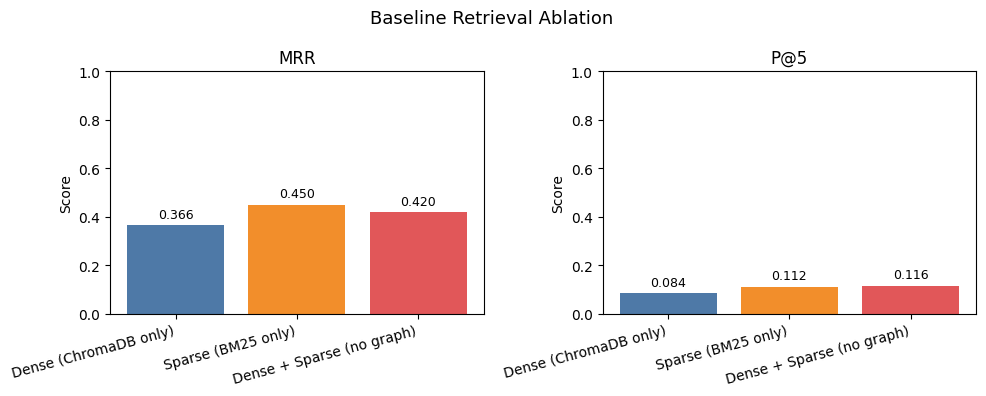

02:03:34  INFO      Plot saved: figures/baseline_ablation.png


Plot saved to figures/baseline_ablation.png


In [7]:
print('Baseline results summary')
print('=' * 60)
for config, label in BASELINE_CONFIGS.items():
    subset = df_baseline[df_baseline['config'] == config]
    mrr = subset['mrr'].mean()
    p5  = subset['p@5'].mean()
    r10 = subset['r@10'].mean()
    n5  = subset['ndcg@5'].mean()
    print(f'{label}:')
    print(f'  MRR={mrr:.4f}  P@5={p5:.4f}  R@10={r10:.4f}  NDCG@5={n5:.4f}')
    logger.info('RESULT  config=%-20s  MRR=%.4f  P@5=%.4f  R@10=%.4f  NDCG@5=%.4f', config, mrr, p5, r10, n5)

print()
if 'query_type' in df_baseline.columns and df_baseline['query_type'].nunique() > 1:
    print('Per-query-type breakdown (dense_sparse config):')
    ds_df = df_baseline[df_baseline['config'] == 'dense_sparse']
    by_type = ds_df.groupby('query_type')[['mrr', 'p@5', 'ndcg@5']].mean().round(4)
    print(by_type.to_string())
    print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['mrr', 'p@5']):
    values = df_baseline.groupby('config')[metric].mean().reindex(BASELINE_CONFIGS.keys())
    labels = list(BASELINE_CONFIGS.values())
    bars = ax.bar(range(len(values)), values.values, color=['#4e79a7', '#f28e2b', '#e15759'])
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')

plt.suptitle('Baseline Retrieval Ablation', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_ablation.png', bbox_inches='tight')
plt.show()
logger.info('Plot saved: figures/baseline_ablation.png')
print('Plot saved to figures/baseline_ablation.png')